In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')
import CCACSP
from my_ica import icaa
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from scipy.signal import welch

In [2]:
raw = mne.io.read_raw_gdf("../data/A07T.gdf", preload=True, stim_channel="auto")
events, event_id = mne.events_from_annotations(raw)
print(event_id)
print(events.shape)

Extracting GDF parameters from ../data/A07T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...


/opt/conda/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Reading 0 ... 681070  =      0.000 ...  2724.280 secs...
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
(605, 3)


In [3]:
raw.drop_channels([ch for ch in ["EOG-left", "EOG-central", "EOG-right"] if ch in raw.ch_names])
raw0 = raw.copy()
raw0._data = raw0._data.copy()

raw_8_30 = raw0.copy()
raw_8_30._data = raw_8_30._data.copy()
raw_8_30.filter(1, 60)
raw_8_30.filter(8, 30)

use = {k: event_id[k] for k in ["769", "770"]}
epochs_o = mne.Epochs(raw_8_30, events, event_id=use, tmin=0.5, tmax=2.5, baseline=None, preload=True)

X = epochs_o.get_data()
y = (epochs_o.events[:, 2] == event_id["770"]).astype(int)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 60 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 60.00 Hz
- Upper transition bandwidth: 15.00 Hz (-6 dB cutoff frequency: 67.50 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 3

In [4]:
clf = Pipeline([
    ("csp", CSP(n_components=6, log=True)),
    ("lda", LDA())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
X = epochs_o.get_data()
y = epochs_o.events[:, 2]
acc = cross_val_score(clf, X, y, cv=cv).mean()
scores = cross_val_score(clf, X, y, cv=cv)
print(scores, scores.mean(), scores.std())
csp = scores.mean()

Computing rank from data with rank=None
    Using tolerance 2.2e-05 (2.2e-16 eps * 22 dim * 4.6e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.3e-05 (2.2e-16 eps * 22 dim * 4.7e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.3e-05 (2.2e-16 eps * 22 dim * 4.7e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

In [5]:
raw_ica = raw0.copy()
raw_ica._data = raw_ica._data.copy()
raw_ica.filter(1, 60)

X = raw_ica.get_data()
S, W, A, mu = icaa(X, n_components=22)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 60 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 60.00 Hz
- Upper transition bandwidth: 15.00 Hz (-6 dB cutoff frequency: 67.50 Hz)
- Filter length: 825 samples (3.300 s)



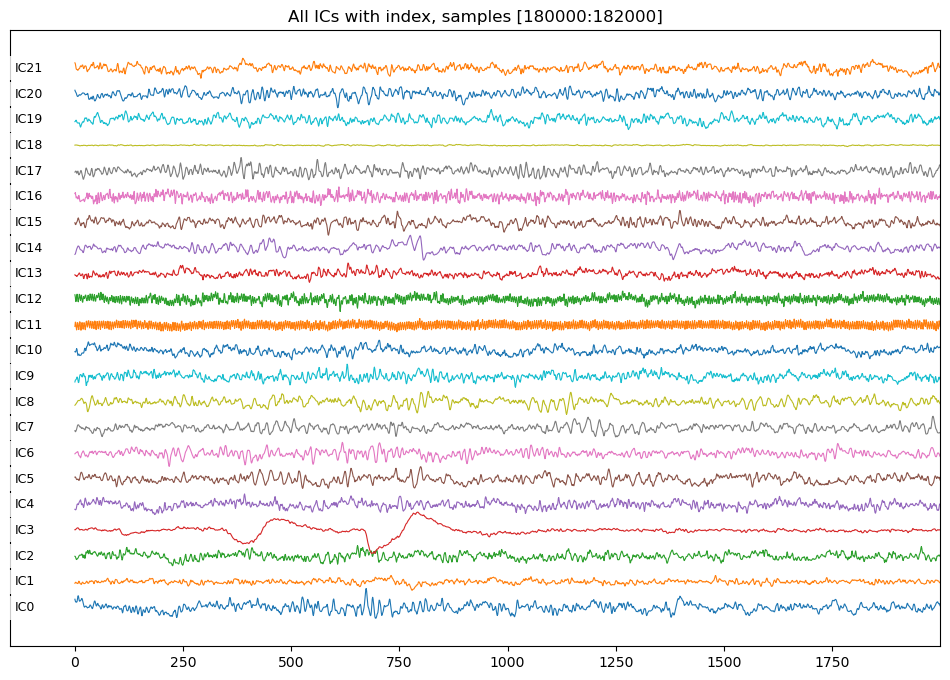

In [6]:
start = 180000
win_len = 2000
win = slice(start, start + win_len)

seg = S[:, win]
step = 8.0 
offset = step * np.arange(seg.shape[0])[:, None]

plt.figure(figsize=(12, 8))
plt.plot((seg + offset).T, linewidth=0.8)

plt.xlim(-150, win_len - 1)

for i in range(seg.shape[0]):
    y = offset[i, 0]
    plt.text(-140, y, f"IC{i}", va="center", fontsize=9,
             bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))

plt.title(f"All ICs with index, samples [{start}:{start+win_len}]")
plt.yticks([])
plt.show()

In [7]:
fs = raw.info["sfreq"]  

In [8]:
def psd_fft(x, fs):
    x = x - x.mean()
    n = x.size
    X = np.fft.rfft(x)
    P = (np.abs(X) ** 2) / n
    f = np.fft.rfftfreq(n, d=1/fs)
    return f, P

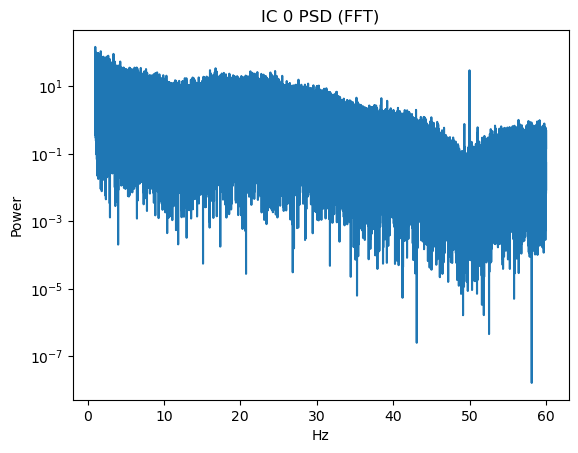

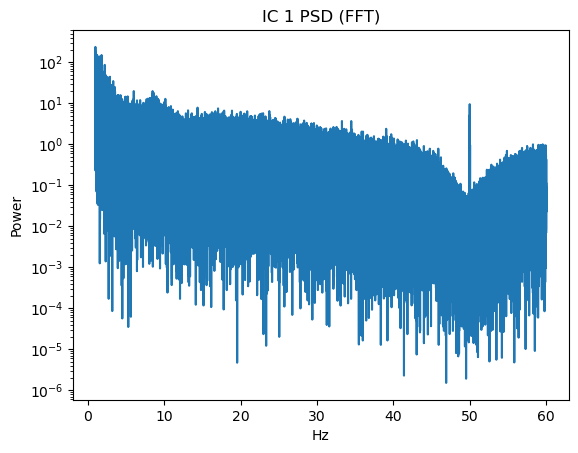

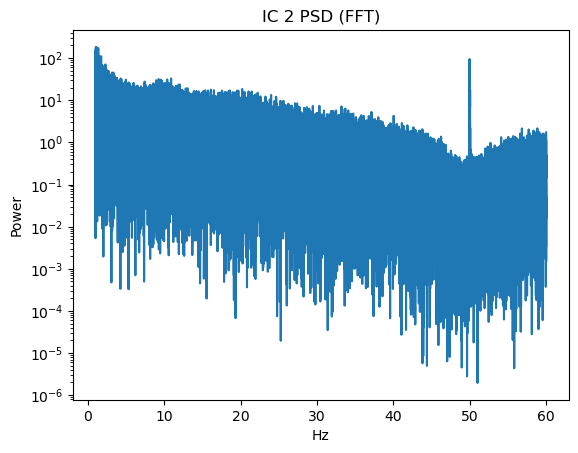

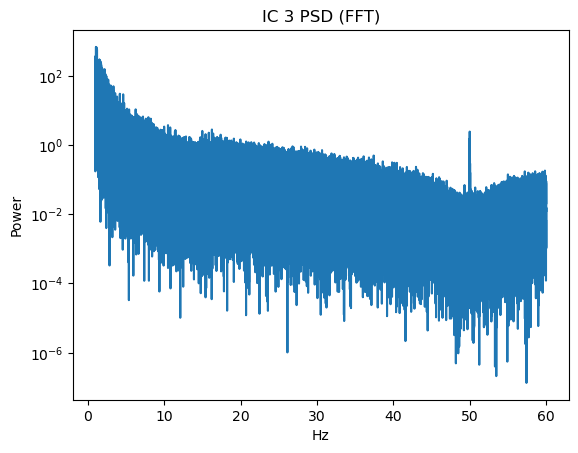

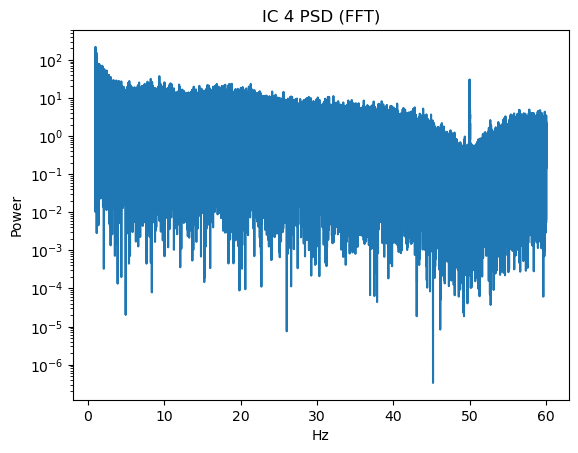

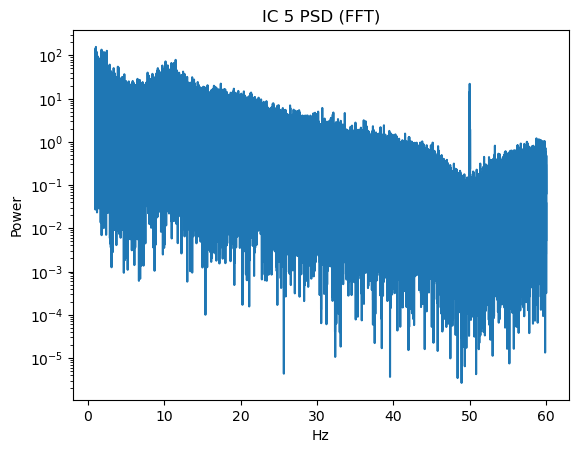

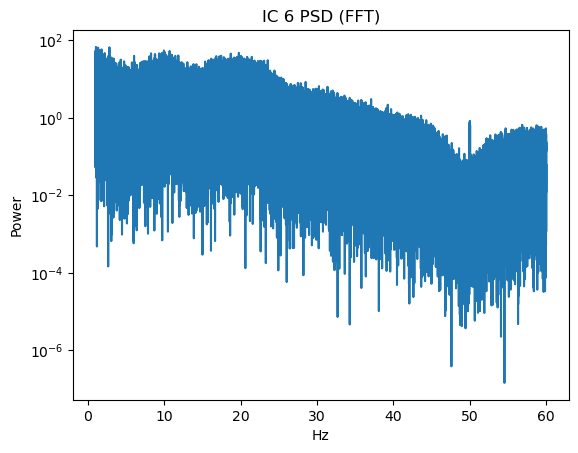

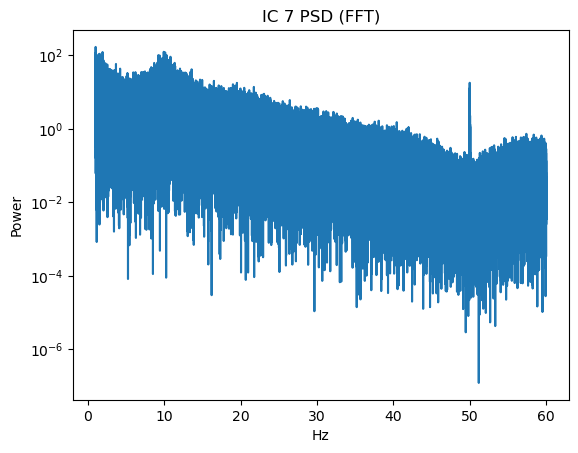

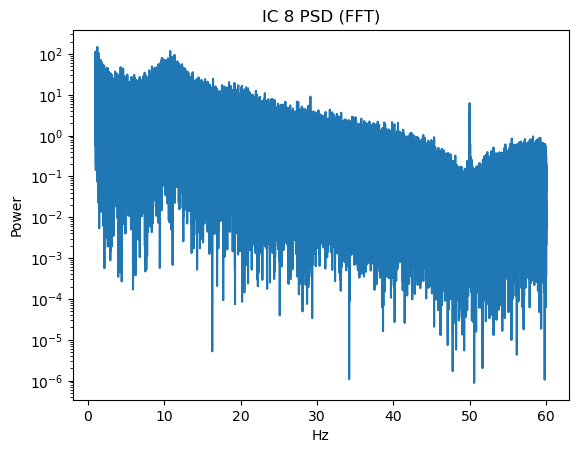

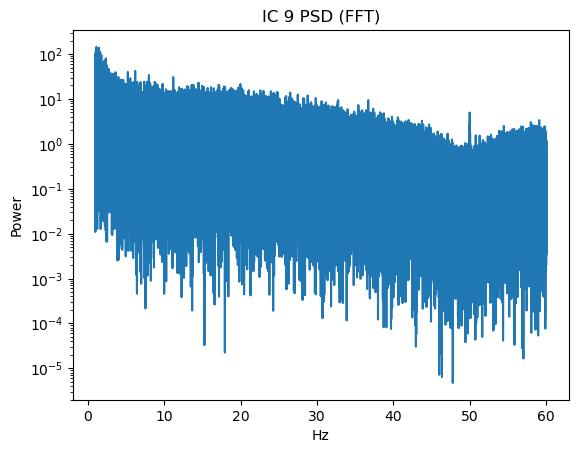

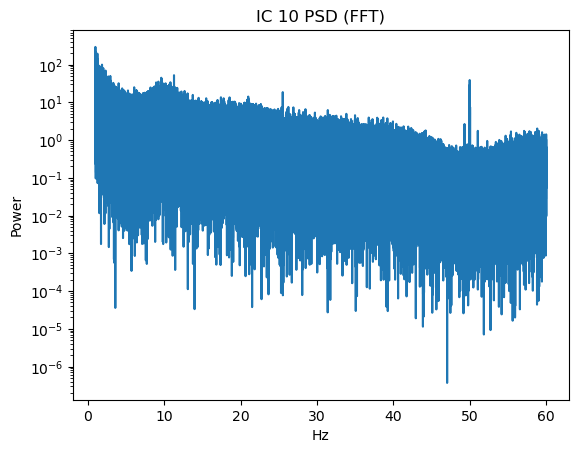

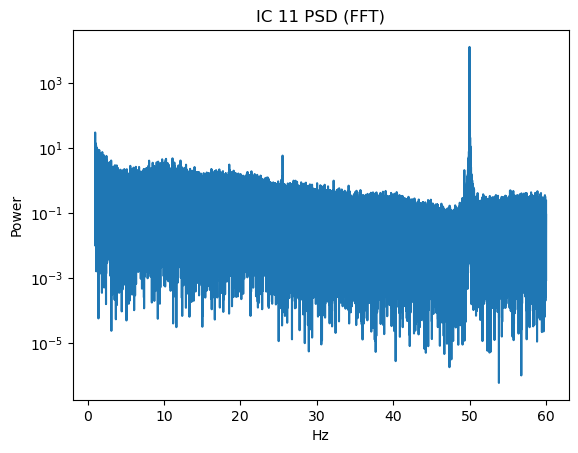

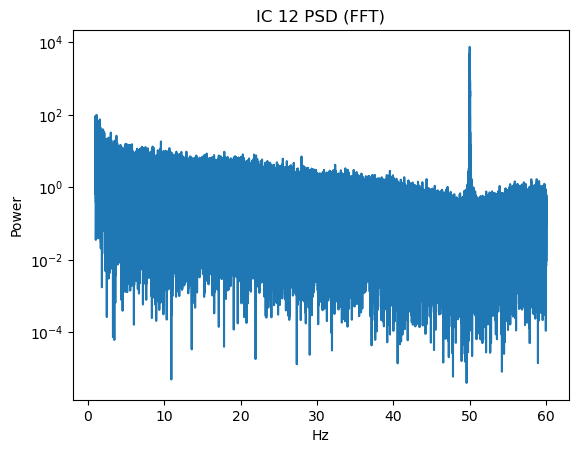

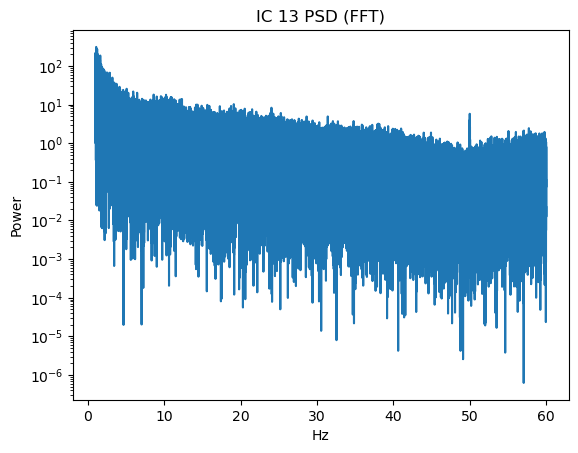

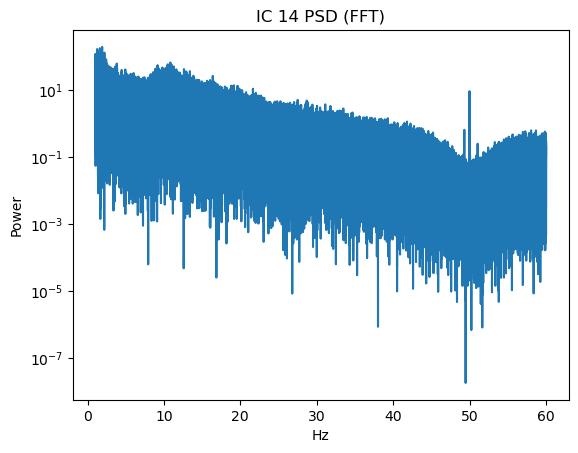

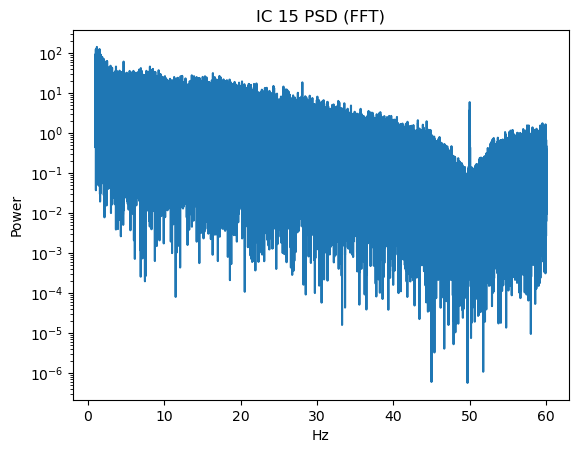

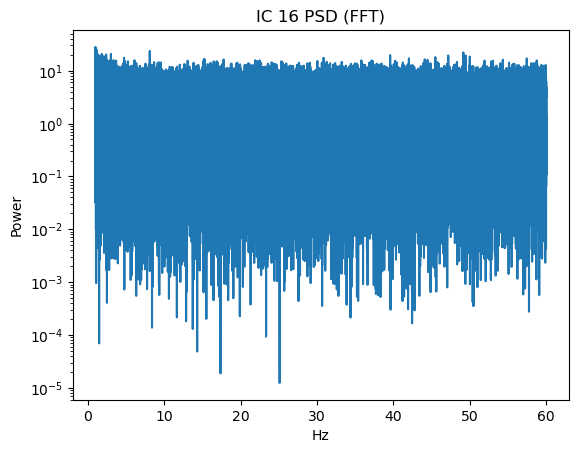

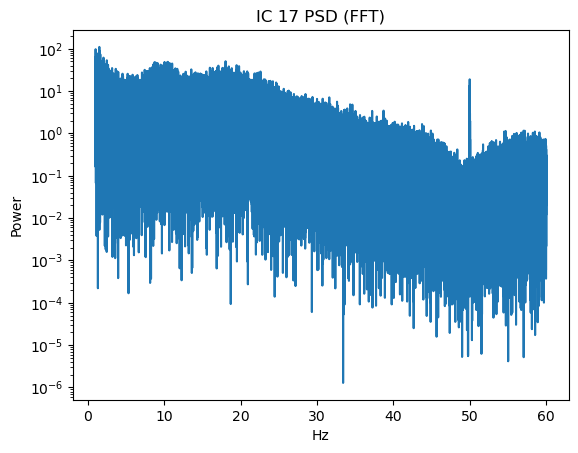

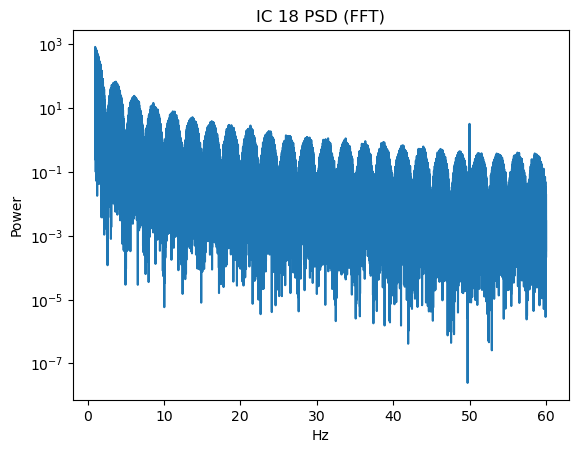

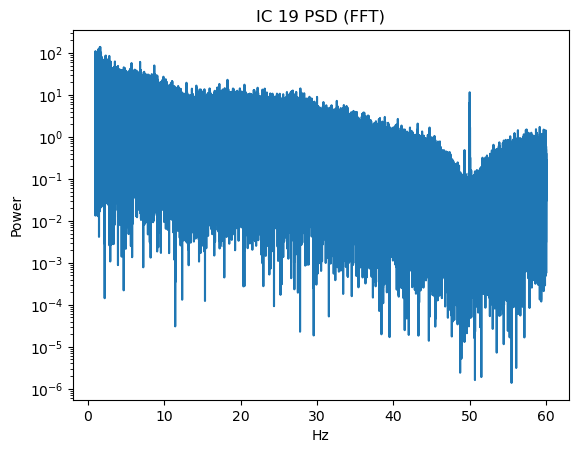

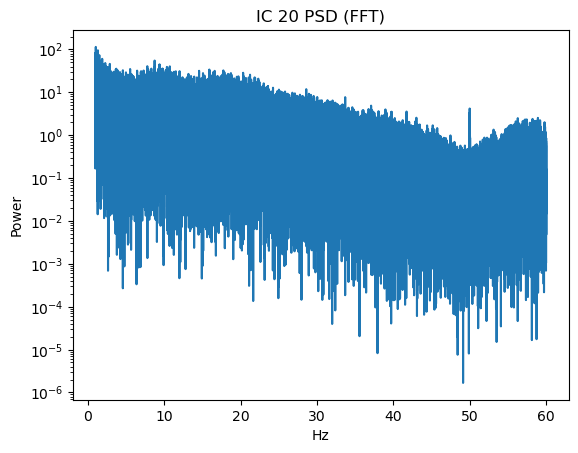

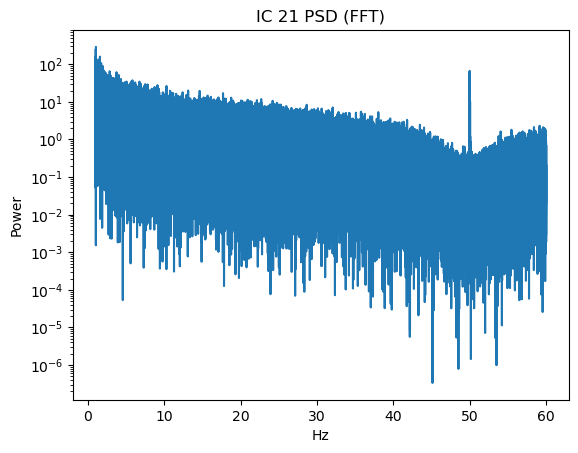

In [9]:
ics = list(range(22))
for i in ics:
    f, P = psd_fft(S[i], fs)
    m = (f >= 1) & (f <= 60)
    plt.figure()
    plt.semilogy(f[m], P[m])
    plt.title(f"IC {i} PSD (FFT)")
    plt.xlabel("Hz")
    plt.ylabel("Power")
    plt.show()

In [10]:
S_used = S

def bandpower(psd, freqs, fmin, fmax):
    m = (freqs >= fmin) & (freqs <= fmax)
    return np.trapz(psd[..., m], freqs[m], axis=-1)

freqs, psd = welch(S_used, fs=fs, nperseg=int(fs*2), axis=1)

P_mu   = bandpower(psd, freqs, 8, 30)
P_low  = bandpower(psd, freqs, 0.5, 4)
P_high = bandpower(psd, freqs, 30, 80)

low_ratio  = P_low  / (P_mu)
high_ratio = P_high / (P_mu)

bad_low  = np.where(low_ratio  > np.quantile(low_ratio,  0.90))[0]
bad_high = np.where(high_ratio > np.quantile(high_ratio, 0.90))[0]

print("low_ratio top:", np.argsort(low_ratio)[-5:][::-1], low_ratio[np.argsort(low_ratio)[-5:][::-1]])
print("high_ratio top:", np.argsort(high_ratio)[-5:][::-1], high_ratio[np.argsort(high_ratio)[-5:][::-1]])

low_ratio top: [ 3 18  1 13 21] [21.46639658 15.55458921  4.66258108  2.88929514  1.43231723]
high_ratio top: [11 12 16  4 13] [20.50494844  3.68070047  1.67297685  0.44454144  0.38639811]


In [11]:
bad = np.argsort(low_ratio)[-2:][::-1].tolist()

S2 = S.copy()
S2[bad, :] = 0.0

X_clean = A @ S2 + mu

raw_clean = raw_ica.copy()
raw_clean._data = raw_clean._data.copy()
raw_clean._data[:] = X_clean         

raw_cls = raw_clean.copy().filter(8, 30)
raw_cls._data = raw_cls._data.copy() 
epochs_i = mne.Epochs(raw_cls, events, event_id=use, tmin=0.5, tmax=2.5, baseline=None, preload=True)

Xep = epochs_i.get_data()
y = epochs_i.events[:, 2]
acc = cross_val_score(clf, Xep, y, cv=cv).mean()
scores = cross_val_score(clf, Xep, y, cv=cv)
print(scores, scores.mean(), scores.std())
csp_ica = scores.mean()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Not setting metadata
144 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 144 events and 501 original time points ...
0 bad epochs dropped
Computing rank from data with rank=None
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4e+09  max singular value)
    Estimated rank (data): 20
    data: rank 20 computed from 22 data channels with 0 projectors
    Setting small da

In [12]:
def ccacsp_cv_score_epochso(epochs_o, num_filt=3, n_splits=5, seed=0):
    X = epochs_o.get_data()          
    y = epochs_o.events[:, 2].copy()

    classes = np.unique(y)
    c0, c1 = classes[0], classes[1]

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = []

    for tr, te in cv.split(np.zeros(len(y)), y):
        Xtr, ytr = X[tr], y[tr]
        X0 = Xtr[ytr == c0]
        X1 = Xtr[ytr == c1]
        filters, clf = CCACSP.train(X0, X1, num_filt)
        pred = np.empty(len(te), dtype=y.dtype)
        for i, idx in enumerate(te):
            out01 = CCACSP.test(X[idx], filters, clf)
            pred[i] = c0 if out01 == 0 else c1

        scores.append((pred == y[te]).mean())

    return np.array(scores)

scores = ccacsp_cv_score_epochso(epochs_o, num_filt=3, n_splits=5, seed=0)
print(scores, scores.mean(), scores.std())
ccacsp = scores.mean()

[0.68965517 0.65517241 0.72413793 0.82758621 0.78571429] 0.7364532019704433 0.06273781467953879


In [13]:
def ccacsp_cv_score(epochs, num_filt=3, n_splits=5, seed=0):
    X = epochs.get_data()
    y = epochs.events[:, 2].copy()

    classes = np.unique(y)
    c0, c1 = classes[0], classes[1]

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = []

    for tr, te in cv.split(np.zeros(len(y)), y):
        Xtr, ytr = X[tr], y[tr]
        X0 = Xtr[ytr == c0]
        X1 = Xtr[ytr == c1]
        filters, clf = CCACSP.train(X0, X1, num_filt)
        pred = np.empty(len(te), dtype=y.dtype)
        for i, idx in enumerate(te):
            out01 = CCACSP.test(X[idx], filters, clf)
            pred[i] = c0 if out01 == 0 else c1

        scores.append((pred == y[te]).mean())

    return np.array(scores)

scores_i = ccacsp_cv_score(epochs_i, num_filt=3, n_splits=5, seed=0)
print(scores_i, scores_i.mean(), scores_i.std())
ccacsp_ica = scores_i.mean()

[0.72413793 0.65517241 0.72413793 0.82758621 0.82142857] 0.7504926108374385 0.06549871955682185


In [14]:
print(csp, csp_ica, ccacsp, ccacsp_ica)

0.7024630541871921 0.70935960591133 0.7364532019704433 0.7504926108374385


In [15]:
with open("../data/results.csv", "a") as f:
    f.write(f"{csp},{csp_ica},{ccacsp},{ccacsp_ica}\n")